# 第 6 章 · 前向链与后向链

苏格拉底三段论：逐步展示规则扫描、事实池增长与目标证明。

配套交互演示：[章节网页](../ch6.html)

## 本节目标

- 逐步模拟前向链
- 观察 known 事实池如何扩展
- 倒推后向链
- 对照 ch6 网页动画

## 1. 规则库与事实

每条规则形如 **IF 条件 THEN 结论**。已知事实放在 `known` 集合；每轮扫描全部规则，触发则把结论加入 known。

目标：证明「苏格拉底终有一死」。

**规则形式**

```text
IF 人(x) THEN 会死(x)
IF 会死(x) THEN 终有一死(x)
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch06"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from reasoning import *
from common.codelens import print_frames as print_codelens

In [2]:
data = load_rules()

In [3]:
print('facts:', data['facts'])

facts: ['人(苏格拉底)']


In [4]:
print('goal:', data['goal'])

goal: 终有一死(苏格拉底)


In [5]:
for r in data['rules']: print(r['id'], r['if'], '=>', r['then'])

R1 ['人(X)'] => 会死(X)
R2 ['会死(X)'] => 终有一死(X)


**思考** · 初始 known 里有什么？

<details><summary>查看答案</summary>

人(苏格拉底)

</details>

## 2. 前向链：逐轮扫描

### 2.1 扫描循环

每轮遍历规则列表；条件已在 known 中则结论入池，直到无新事实。

**前向链**

```text
while changed:
  for rule in rules:
    if all(cond in known for cond in rule.if):
      known.add(rule.then)
```

In [6]:
fc_frames = codelens_forward_chain()

In [7]:
print_codelens(fc_frames)

── Step 0 ── 初始化
   执行: known = facts
   known = ['人(苏格拉底)']
   goal = '终有一死(苏格拉底)'

── Step 1 ── 第 1 轮触发 2 条规则
   执行: round 1 scan rules
   新增 = ['R1: 人(苏格拉底) ⇒ 会死(苏格拉底)', 'R2: 会死(苏格拉底) ⇒ 终有一死(苏格拉底)']
   known = ['人(苏格拉底)', '会死(苏格拉底)', '终有一死(苏格拉底)']

── Step 2 ── 检查目标是否在 known 中
   执行: check goal
   goal = '终有一死(苏格拉底)'
    proved = True



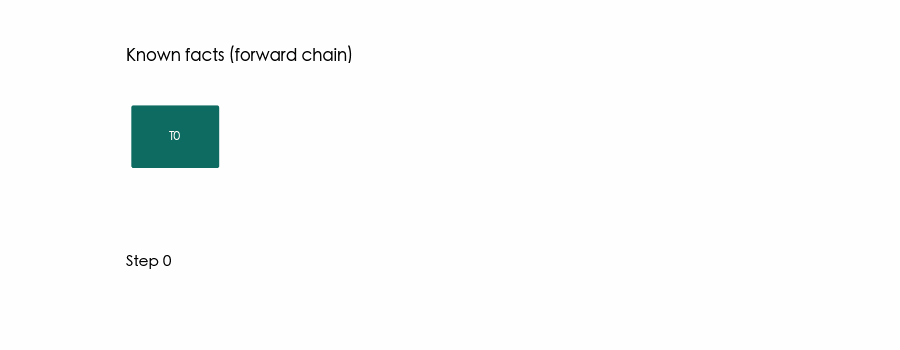

In [8]:
animate_forward_chain()

In [9]:
for line in forward_chain(): print(line)

初始事实: 人(苏格拉底)
第 1 轮: R1: 人(苏格拉底) ⇒ 会死(苏格拉底); R2: 会死(苏格拉底) ⇒ 终有一死(苏格拉底)
目标 终有一死(苏格拉底): ✓


**思考** · 第一轮新增哪条事实？

<details><summary>查看答案</summary>

会死(苏格拉底)，由 R1 触发。

</details>

**思考** · 几轮后目标成立？

<details><summary>查看答案</summary>

第二轮 R2 推出终有一死(苏格拉底)。

</details>

## 3. 后向链：目标分解

从目标出发，匹配规则结论，把前提变为子目标，直到子目标在 known 中。

**后向**

```text
prove(goal):
  match rule where rule.then == goal
  prove each subgoal in rule.if
```

In [10]:
for line in backward_chain(): print(' ', line)

  目标: 终有一死(苏格拉底)
  子目标: 会死(苏格拉底) (R2)
  子目标: 人(苏格拉底) (R1)
  匹配事实: True → 证明成立


## 4. 前向 vs 后向

**前向**：数据驱动，适合已知事实多、目标未知的诊断。

**后向**：目标驱动，适合证明特定结论。

**思考** · 本例为何前向两轮就够？

<details><summary>查看答案</summary>

规则链短，事实少，每轮都能触发新结论。

</details>

## 小结

前向链用 known 事实池驱动推理；后向链从 goal 倒推子目标。

对照 [ch6.html](../ch6.html) 步进动画验证每一轮 known 变化。

## 练习

1. 若增加规则「哲学家(x)→人(x)」，需几轮才能证明目标？
2. 后向链若先匹配 R1 而非 R2，证明路径有何不同？